<a href="https://colab.research.google.com/github/studerAD15/churn_prediction/blob/main/Telecom_Churn_Prediction_Complete__final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📡 Telecom Customer Churn Prediction
### End-to-End ML Pipeline — Ready for Frontend & Backend Integration

**Pipeline Overview:**
1. Install & Import Libraries
2. Data Generation / Loading
3. EDA (Exploratory Data Analysis)
4. Preprocessing & Feature Engineering
5. Model Training (Multiple Models)
6. Model Evaluation & Comparison
7. Hyperparameter Tuning
8. Feature Importance & SHAP Explainability
9. Save Model & Artifacts
10. FastAPI Backend Code (ready to deploy)
11. Sample Frontend HTML (ready to use)

BY-ADITYA CHHIKARA
EMAIL=adichhikaraa@gmail.com


In [1]:
!pip install shap fastapi uvicorn pydantic joblib imbalanced-learn xgboost lightgbm --quiet

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

from imblearn.over_sampling import SMOTE

import shap

import joblib
import json
import os

print(' All libraries imported successfully!')

 All libraries imported successfully!


In [2]:

!pip install kaggle --quiet

import os, json

KAGGLE_API_TOKEN = "KGAT_979ee625ec79972e223e5bcfe7a78f36"

import urllib.request

os.makedirs('/root/.kaggle', exist_ok=True)
req = urllib.request.Request(
    'https://www.kaggle.com/api/v1/users/me',
    headers={'Authorization': f'Bearer {KAGGLE_API_TOKEN}'}
)
try:
    with urllib.request.urlopen(req) as resp:
        user_info = json.loads(resp.read())
        username = user_info.get('userName') or user_info.get('username', 'user')
        print(f'✅ Authenticated as: {username}')
except Exception as e:
    print(f'⚠️  Could not auto-fetch username ({e}). Using token-only mode.')
    username = 'user'

kaggle_creds = {"username": username, "key": KAGGLE_API_TOKEN}
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_creds, f)
os.chmod('/root/.kaggle/kaggle.json', 0o600)

os.environ['KAGGLE_API_TOKEN'] = KAGGLE_API_TOKEN
os.environ['KAGGLE_USERNAME']  = username
os.environ['KAGGLE_KEY']       = KAGGLE_API_TOKEN

print('✅ Kaggle credentials configured.')

print('\n⬇️  Downloading IBM Telco Customer Churn dataset...')
os.makedirs('/content/data', exist_ok=True)
!kaggle datasets download -d blastchar/telco-customer-churn --unzip -p /content/data/

# ── Load into DataFrame ───────────────────────────────────
import pandas as pd
import numpy as np

df = pd.read_csv('/content/data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Fix TotalCharges (spaces for brand-new customers → NaN, filled by imputer later)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Convert Churn to binary int  (Yes → 1, No → 0)
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

print(f'\n✅ Real dataset loaded!')
print(f'   Shape         : {df.shape}')
print(f'   Churn rate    : {df["Churn"].mean():.1%}')
print(f'   Missing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}')
df.head()

⚠️  Could not auto-fetch username (HTTP Error 404: Not Found). Using token-only mode.
✅ Kaggle credentials configured.

⬇️  Downloading IBM Telco Customer Churn dataset...
Dataset URL: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
License(s): copyright-authors
100% 172k/172k [00:00<00:00, 70.0MB/s]


✅ Real dataset loaded!
   Shape         : (7043, 21)
   Churn rate    : 26.5%
   Missing values:
TotalCharges    11
dtype: int64


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


Exploratory Data Analysis (EDA)

In [3]:
print('=== Dataset Info ===')
print(df.dtypes)
print('\n=== Null Values ===')
print(df.isnull().sum()[df.isnull().sum() > 0])
print('\n=== Basic Stats ===')
df.describe()

=== Dataset Info ===
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

=== Null Values ===
TotalCharges    11
dtype: int64

=== Basic Stats ===


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,7043.000000,7043.000000,7043.000000,7032.000000,7043.000000
mean,0.162147,32.371149,64.761692,2283.300441,0.265370
std,0.368612,24.559481,30.090047,2266.771362,0.441561
min,0.000000,0.000000,18.250000,18.800000,0.000000
25%,0.000000,9.000000,35.500000,401.450000,0.000000
50%,0.000000,29.000000,70.350000,1397.475000,0.000000
75%,0.000000,55.000000,89.850000,3794.737500,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


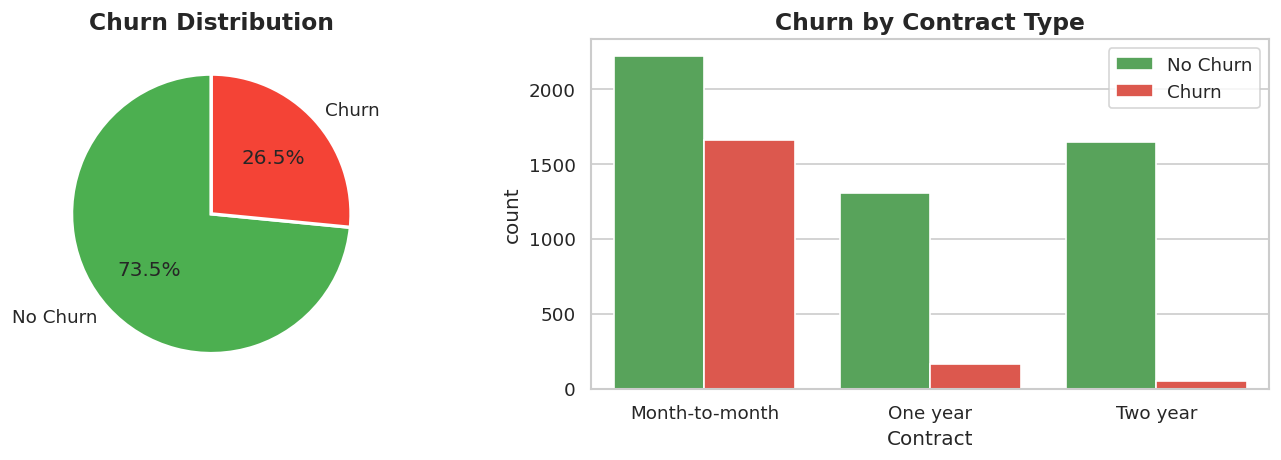

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

churn_counts = df['Churn'].value_counts()
axes[0].pie(
    churn_counts,
    labels=['No Churn', 'Churn'],
    autopct='%1.1f%%',
    colors=['#4CAF50', '#F44336'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Churn Distribution', fontsize=14, fontweight='bold')

sns.countplot(data=df, x='Contract', hue='Churn',
              palette={0:'#4CAF50', 1:'#F44336'}, ax=axes[1])
axes[1].set_title('Churn by Contract Type', fontsize=14, fontweight='bold')
axes[1].legend(['No Churn', 'Churn'])

plt.tight_layout()
plt.savefig('churn_distribution.png', bbox_inches='tight')
plt.show()

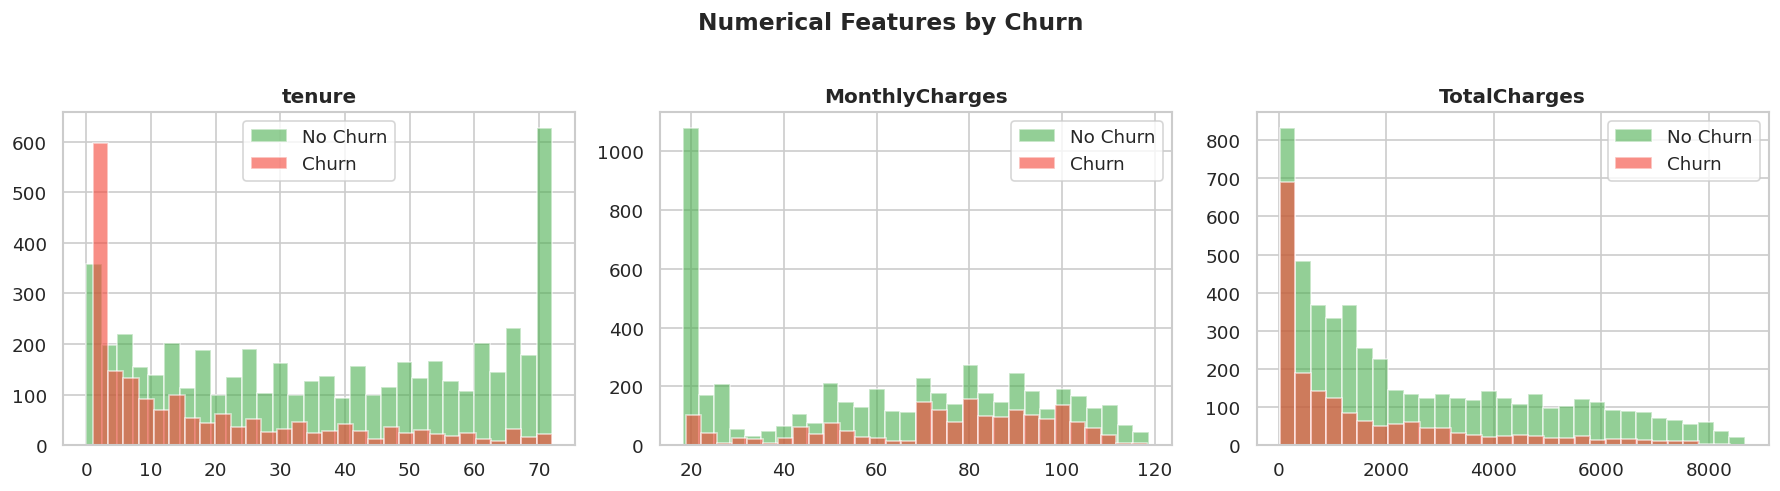

In [5]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(num_cols):
    for label, color in zip([0, 1], ['#4CAF50', '#F44336']):
        axes[i].hist(
            df[df['Churn'] == label][col].dropna(),
            bins=30, alpha=0.6, color=color,
            label='No Churn' if label == 0 else 'Churn'
        )
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].legend()

plt.suptitle('Numerical Features by Churn', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('feature_distributions.png', bbox_inches='tight')
plt.show()

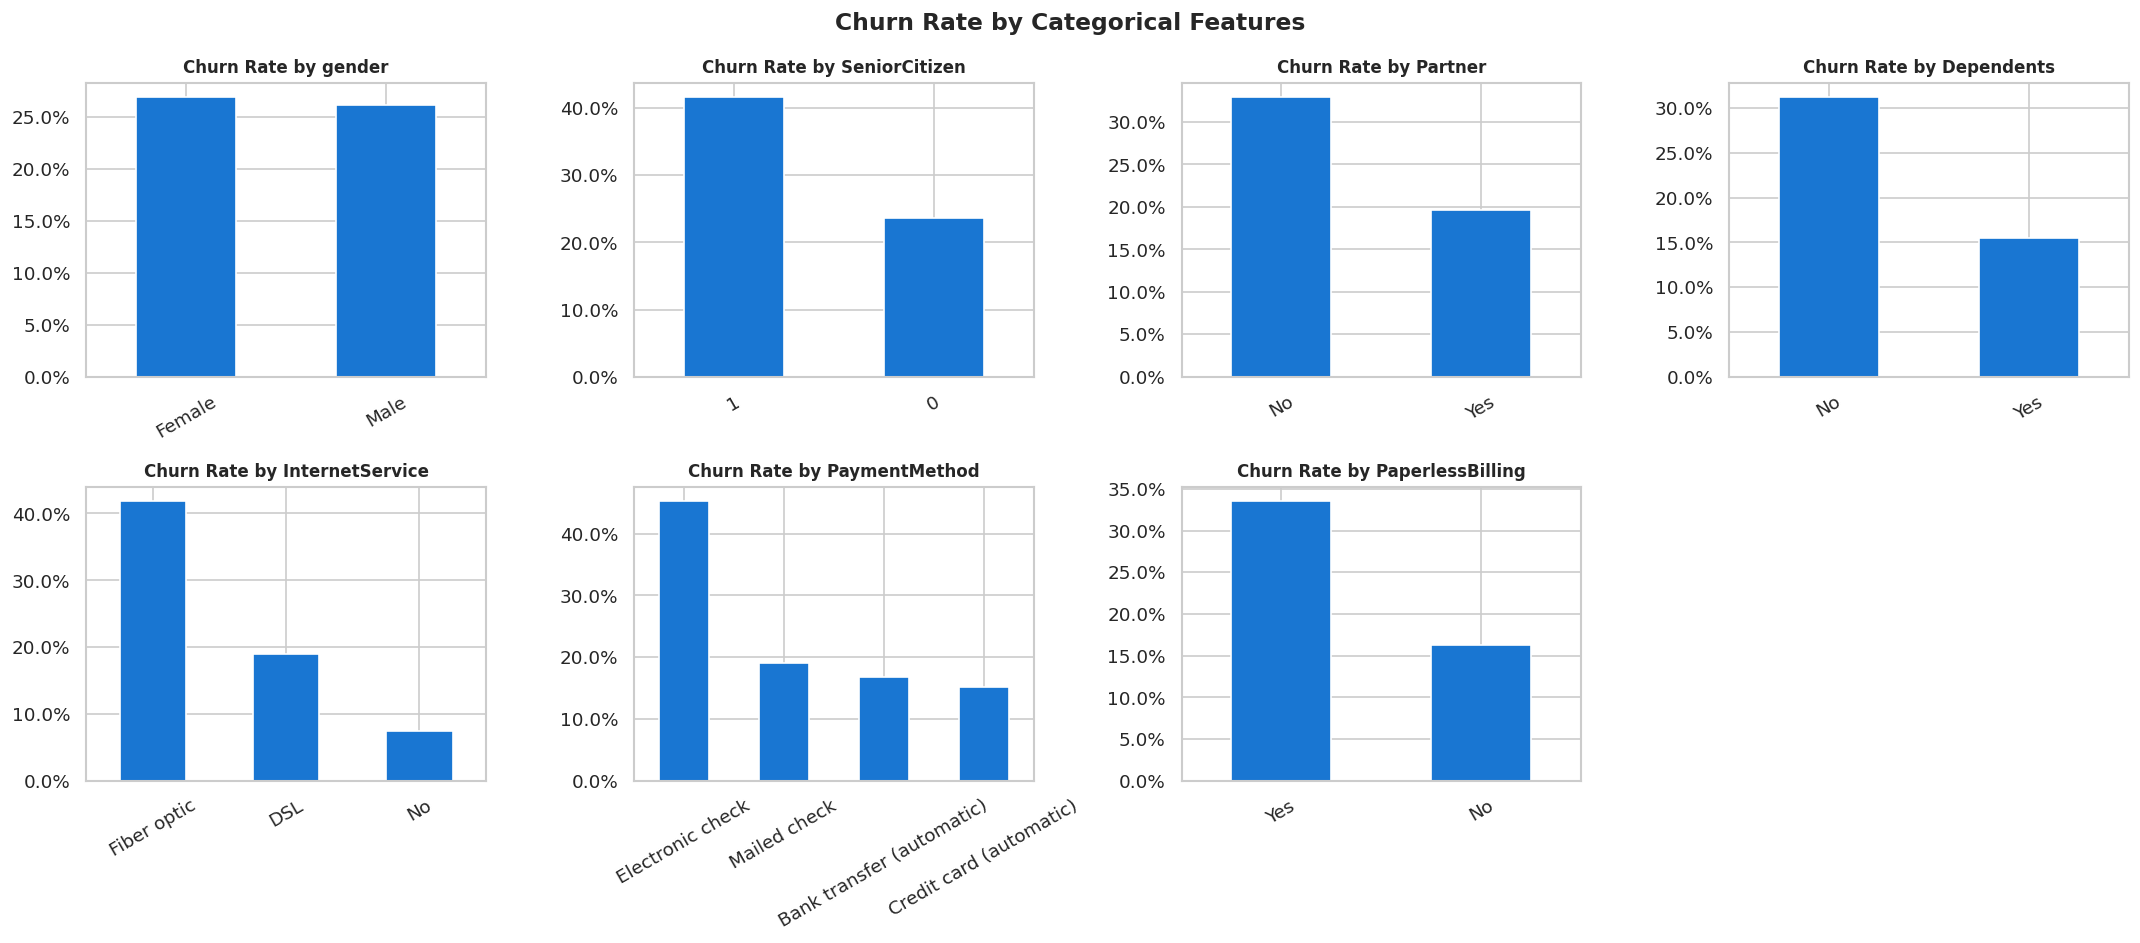

In [6]:
cat_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
                'InternetService', 'PaymentMethod', 'PaperlessBilling']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    churn_rates = df.groupby(col)['Churn'].mean().sort_values(ascending=False)
    churn_rates.plot(kind='bar', ax=axes[i], color='#1976D2', edgecolor='white', rot=30)
    axes[i].set_title(f'Churn Rate by {col}', fontsize=10, fontweight='bold')
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    axes[i].set_xlabel('')

axes[-1].set_visible(False)  # hide last empty axis
plt.suptitle('Churn Rate by Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('categorical_churn_rates.png', bbox_inches='tight')
plt.show()

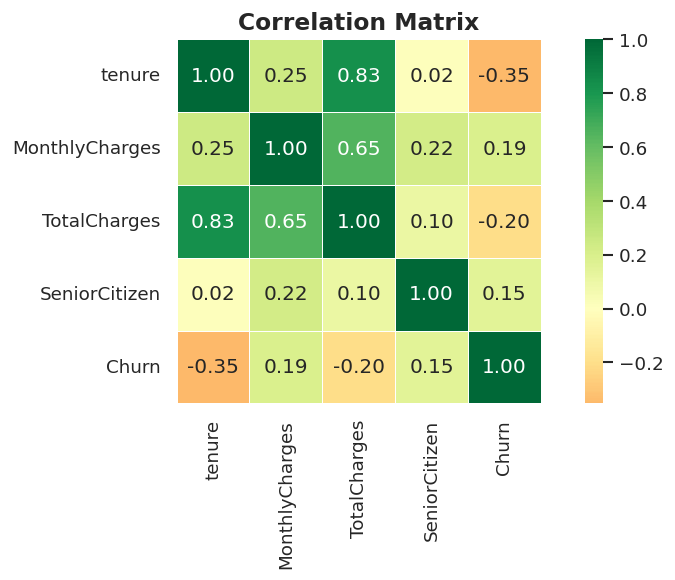

In [7]:
plt.figure(figsize=(8, 5))
corr = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, square=True)
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

## Preprocessing & Feature Engineering

In [8]:
df_ml = df.drop(columns=['customerID'])

# Avg monthly spend
df_ml['AvgMonthlySpend'] = df_ml['TotalCharges'] / (df_ml['tenure'] + 1)

# Has any streaming service
df_ml['HasStreaming'] = (
    (df_ml['StreamingTV'] == 'Yes') | (df_ml['StreamingMovies'] == 'Yes')
).astype(int)

# Number of add-on services
addons = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']
df_ml['NumAddons'] = sum((df_ml[col] == 'Yes').astype(int) for col in addons)

# Is long-term customer?
df_ml['LongTermCustomer'] = (df_ml['tenure'] > 24).astype(int)

print('✅ Feature engineering done. New shape:', df_ml.shape)
df_ml.head(3)

✅ Feature engineering done. New shape: (7043, 24)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AvgMonthlySpend,HasStreaming,NumAddons,LongTermCustomer
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,Month-to-month,Yes,Electronic check,29.85,29.85,0,14.925000,0,1,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,One year,No,Mailed check,56.95,1889.50,0,53.985714,0,2,1
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,Month-to-month,Yes,Mailed check,53.85,108.15,1,36.050000,0,2,0


In [9]:

X = df_ml.drop(columns=['Churn'])
y = df_ml['Churn']


categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols   = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f'Categorical features ({len(categorical_cols)}): {categorical_cols}')
print(f'Numerical features   ({len(numerical_cols)}):   {numerical_cols}')

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer,  numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_proc, y_train)

print(f'\nTraining set  : {X_train_proc.shape}')
print(f'After SMOTE   : {X_train_bal.shape}')
print(f'Test set      : {X_test_proc.shape}')

Categorical features (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numerical features   (8):   ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend', 'HasStreaming', 'NumAddons', 'LongTermCustomer']

Training set  : (5634, 49)
After SMOTE   : (8278, 49)
Test set      : (1409, 49)


In [10]:
# Define models to compare
models = {
    'Logistic Regression'     : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'           : DecisionTreeClassifier(random_state=42),
    'Random Forest'           : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting'       : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost'                 : XGBClassifier(n_estimators=100, random_state=42,
                                               eval_metric='logloss', verbosity=0),
    'LightGBM'                : LGBMClassifier(n_estimators=100, random_state=42, verbose=-1),
}

results = {}

for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    y_pred      = model.predict(X_test_proc)
    y_prob      = model.predict_proba(X_test_proc)[:, 1]

    results[name] = {
        'Accuracy'  : accuracy_score(y_test, y_pred),
        'Precision' : precision_score(y_test, y_pred),
        'Recall'    : recall_score(y_test, y_pred),
        'F1-Score'  : f1_score(y_test, y_pred),
        'ROC-AUC'   : roc_auc_score(y_test, y_prob),
        'model'     : model,
        'y_prob'    : y_prob,
        'y_pred'    : y_pred,
    }
    print(f'  ✅ {name:30s} | AUC: {results[name]["ROC-AUC"]:.4f} | F1: {results[name]["F1-Score"]:.4f}')

print('\n✅ All models trained!')

  ✅ Logistic Regression            | AUC: 0.8451 | F1: 0.6233
  ✅ Decision Tree                  | AUC: 0.6615 | F1: 0.5050
  ✅ Random Forest                  | AUC: 0.8166 | F1: 0.5516
  ✅ Gradient Boosting              | AUC: 0.8396 | F1: 0.6167
  ✅ XGBoost                        | AUC: 0.8205 | F1: 0.5734
  ✅ LightGBM                       | AUC: 0.8337 | F1: 0.5974

✅ All models trained!


In [11]:

metrics_df = pd.DataFrame({
    name: {k: v for k, v in res.items() if k not in ['model', 'y_prob', 'y_pred']}
    for name, res in results.items()
}).T.sort_values('ROC-AUC', ascending=False)

print('=== Model Comparison ===')
print(metrics_df.to_string(float_format='{:.4f}'.format))

=== Model Comparison ===
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.7495     0.5187  0.7807    0.6233   0.8451
Gradient Boosting      0.7786     0.5705  0.6711    0.6167   0.8396
LightGBM               0.7828     0.5881  0.6070    0.5974   0.8337
XGBoost                0.7750     0.5772  0.5695    0.5734   0.8205
Random Forest          0.7658     0.5608  0.5428    0.5516   0.8166
Decision Tree          0.7175     0.4721  0.5428    0.5050   0.6615


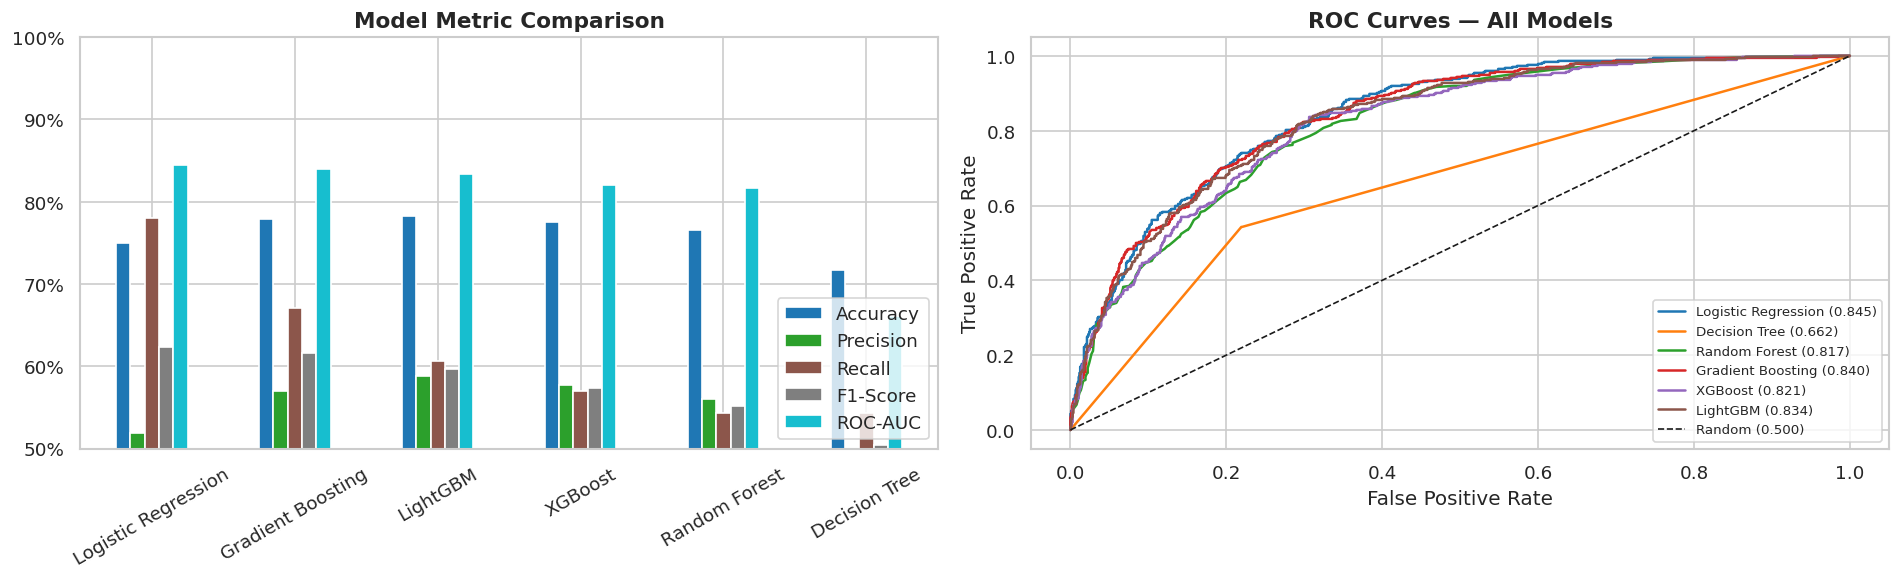

In [12]:

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart of metrics
metrics_df[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']].plot(
    kind='bar', ax=axes[0], colormap='tab10', edgecolor='white', rot=30
)
axes[0].set_title('Model Metric Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylim(0.5, 1.0)
axes[0].legend(loc='lower right')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# ROC curves
colors = plt.cm.tab10.colors
for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    axes[1].plot(fpr, tpr, label=f"{name} ({res['ROC-AUC']:.3f})", color=color, lw=1.5)

axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random (0.500)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves — All Models', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()

🏆 Best Model: Logistic Regression

              precision    recall  f1-score   support

    No Churn       0.90      0.74      0.81      1035
       Churn       0.52      0.78      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409



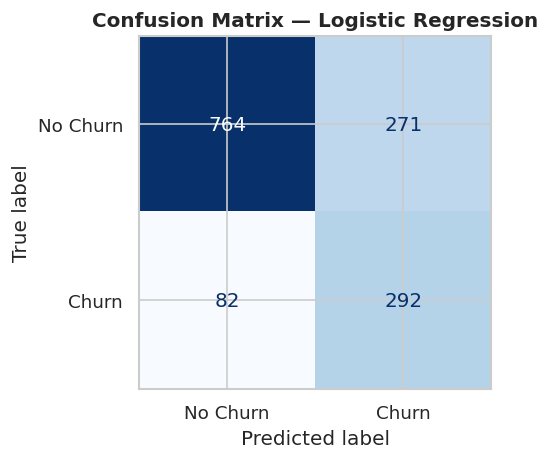

In [13]:
best_model_name = metrics_df['ROC-AUC'].idxmax()
best_result     = results[best_model_name]

print(f'🏆 Best Model: {best_model_name}')
print('\n' + classification_report(y_test, best_result['y_pred'],
                                    target_names=['No Churn', 'Churn']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, best_result['y_pred']),
    display_labels=['No Churn', 'Churn']
).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — {best_model_name}', fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight')
plt.show()

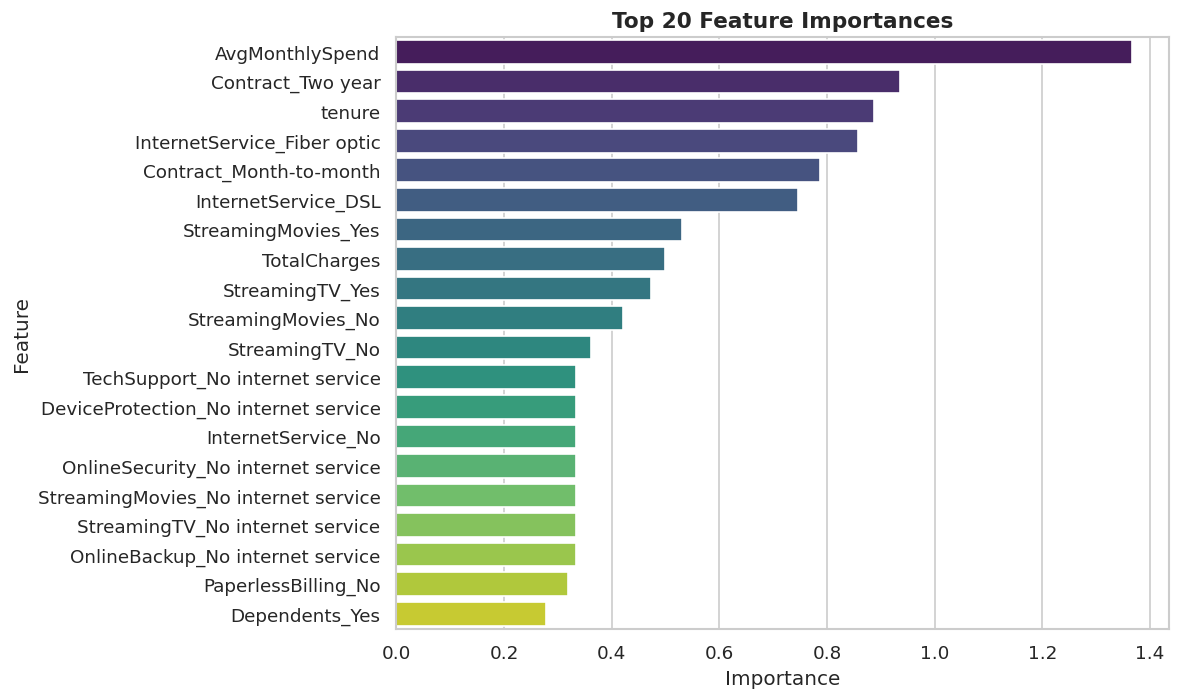

                             Feature  Importance
                     AvgMonthlySpend    1.366671
                   Contract_Two year    0.936383
                              tenure    0.887212
         InternetService_Fiber optic    0.857581
             Contract_Month-to-month    0.786490
                 InternetService_DSL    0.746682
                 StreamingMovies_Yes    0.531420
                        TotalCharges    0.498946
                     StreamingTV_Yes    0.473349
                  StreamingMovies_No    0.420522
                      StreamingTV_No    0.362450
     TechSupport_No internet service    0.333956
DeviceProtection_No internet service    0.333956
                  InternetService_No    0.333956
  OnlineSecurity_No internet service    0.333956
 StreamingMovies_No internet service    0.333956
     StreamingTV_No internet service    0.333956
    OnlineBackup_No internet service    0.333956
                 PaperlessBilling_No    0.319627
                    

In [17]:
cat_feature_names = preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(categorical_cols)
all_feature_names = np.array(numerical_cols + cat_feature_names.tolist())

# Get the best model
best_model = best_result['model']

# Determine feature importances based on model type
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
elif hasattr(best_model, 'coef_'):
    # For linear models like Logistic Regression, use absolute coefficients
    # Assuming binary classification, taking the absolute coefficients for the positive class
    importances = np.abs(best_model.coef_[0])
else:
    print("Model does not have feature importances or coefficients attribute.")
    importances = np.zeros(len(all_feature_names)) # Fallback to zero importance

feat_imp_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values('Importance', ascending=False).head(20)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature',
            palette='viridis', edgecolor='white')
plt.title('Top 20 Feature Importances', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()
print(feat_imp_df.to_string(index=False))

Computing SHAP values (may take 30–60 sec)...


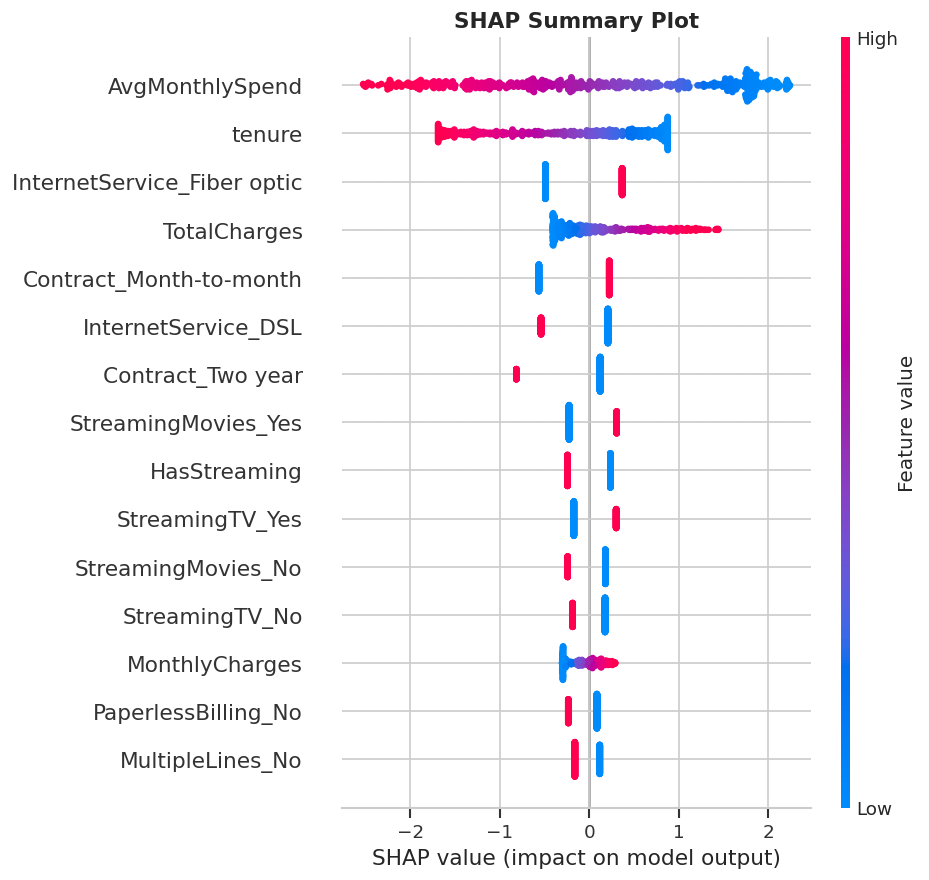

✅ SHAP done!


In [20]:
print('Computing SHAP values (may take 30–60 sec)...')

best_model = best_result['model']

# Use appropriate explainer based on model type
if isinstance(best_model, (XGBClassifier, LGBMClassifier, RandomForestClassifier, DecisionTreeClassifier, GradientBoostingClassifier)):
    explainer = shap.TreeExplainer(best_model)
elif isinstance(best_model, LogisticRegression):
    # For linear models, use LinearExplainer with a background dataset
    explainer = shap.LinearExplainer(best_model, X_train_bal)
else:
    # For other models, use KernelExplainer with a suitable background dataset
    explainer = shap.KernelExplainer(best_model.predict_proba, shap.sample(X_train_bal, 100))

shap_values = explainer.shap_values(X_test_proc[:500])

# For binary classification, shap_values can be a list [shap_values_for_class_0, shap_values_for_class_1]
# We usually want the shap values for the positive class (churn)
if isinstance(shap_values, list):
    sv = shap_values[1] # Take SHAP values for the positive class (churn)
else:
    sv = shap_values

plt.figure(figsize=(10, 6))
shap.summary_plot(sv, X_test_proc[:500],
                  feature_names=all_feature_names, show=False, max_display=15)
plt.title('SHAP Summary Plot', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', bbox_inches='tight')
plt.show()
print('✅ SHAP done!')

In [21]:
os.makedirs('churn_model_artifacts', exist_ok=True)

best_model = best_result['model']

joblib.dump(best_model, 'churn_model_artifacts/churn_model.pkl')

# Save preprocessor
joblib.dump(preprocessor, 'churn_model_artifacts/preprocessor.pkl')

# Save feature config so the backend knows which columns to expect
feature_config = {
    'numerical_cols'    : numerical_cols,
    'categorical_cols'  : categorical_cols,
    'all_feature_names' : all_feature_names.tolist(),
    'model_name'        : best_model_name,
    'best_params'       : {}, # No grid search was performed
    'test_auc'          : float(best_result['ROC-AUC']),
    'test_f1'           : float(best_result['F1-Score']),
}

with open('churn_model_artifacts/feature_config.json', 'w') as f:
    json.dump(feature_config, f, indent=2)

print('✅ Artifacts saved:')
for f in os.listdir('churn_model_artifacts'):
    print(f'   ├── {f}')

# Optional — download to local machine in Colab
# from google.colab import files
# import shutil
# shutil.make_archive('churn_model_artifacts', 'zip', 'churn_model_artifacts')
# files.download('churn_model_artifacts.zip')

✅ Artifacts saved:
   ├── preprocessor.pkl
   ├── feature_config.json
   ├── churn_model.pkl


In [22]:
backend_code = '''
# ─────────────────────────────────────────────────────────────────────────────
#  main.py — FastAPI Churn Prediction Backend
#  Run with:  uvicorn main:app --reload --host 0.0.0.0 --port 8000
#  Deploy to: Render · Railway · Fly.io · Google Cloud Run
# ─────────────────────────────────────────────────────────────────────────────

from fastapi import FastAPI, HTTPException
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel, Field
from typing import Optional
import joblib
import json
import numpy as np
import pandas as pd

app = FastAPI(
    title="Telecom Churn Prediction API",
    version="1.0.0",
    description="Predicts whether a telecom customer will churn."
)

# ── CORS (allow your frontend origin) ────────────────────
app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],   # replace * with your frontend URL in production
    allow_methods=["*"],
    allow_headers=["*"],
)

# ── Load artifacts ────────────────────────────────────────
model       = joblib.load("churn_model_artifacts/churn_model.pkl")
preprocessor = joblib.load("churn_model_artifacts/preprocessor.pkl")
with open("churn_model_artifacts/feature_config.json") as f:
    config = json.load(f)


# ── Request schema ────────────────────────────────────────
class CustomerData(BaseModel):
    gender              : str  = Field("Male",             example="Female")
    SeniorCitizen       : int  = Field(0,                  example=0)
    Partner             : str  = Field("Yes",              example="No")
    Dependents          : str  = Field("No",               example="Yes")
    tenure              : int  = Field(12,                 example=24)
    PhoneService        : str  = Field("Yes",              example="Yes")
    MultipleLines       : str  = Field("No",               example="Yes")
    InternetService     : str  = Field("Fiber optic",      example="DSL")
    OnlineSecurity      : str  = Field("No",               example="Yes")
    OnlineBackup        : str  = Field("No",               example="No")
    DeviceProtection    : str  = Field("No",               example="Yes")
    TechSupport         : str  = Field("No",               example="No")
    StreamingTV         : str  = Field("Yes",              example="No")
    StreamingMovies     : str  = Field("Yes",              example="No")
    Contract            : str  = Field("Month-to-month",   example="Two year")
    PaperlessBilling    : str  = Field("Yes",              example="No")
    PaymentMethod       : str  = Field("Electronic check", example="Bank transfer (automatic)")
    MonthlyCharges      : float = Field(70.5,              example=55.0)
    TotalCharges        : Optional[float] = Field(None,    example=1320.0)


# ── Feature engineering (must mirror the notebook) ───────
def engineer_features(data: dict) -> pd.DataFrame:
    df = pd.DataFrame([data])
    tenure = df["tenure"].iloc[0]
    total  = df["TotalCharges"].iloc[0]
    if total is None or pd.isna(total):
        total = df["MonthlyCharges"].iloc[0] * max(tenure, 1)
        df["TotalCharges"] = total
    df["AvgMonthlySpend"]  = total / (tenure + 1)
    df["HasStreaming"]     = int(
        df["StreamingTV"].iloc[0] == "Yes" or df["StreamingMovies"].iloc[0] == "Yes"
    )
    addons = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport"]
    df["NumAddons"]        = sum(int(df[a].iloc[0] == "Yes") for a in addons)
    df["LongTermCustomer"] = int(tenure > 24)
    return df


# ── Endpoints ─────────────────────────────────────────────
@app.get("/")
def root():
    return {"message": "Telecom Churn Prediction API is live 🚀",
            "docs": "/docs"}


@app.get("/model-info")
def model_info():
    return {
        "model"     : config["model_name"],
        "test_auc"  : round(config["test_auc"], 4),
        "test_f1"   : round(config["test_f1"], 4),
        "best_params": config["best_params"],
    }


@app.post("/predict")
def predict(customer: CustomerData):
    try:
        df = engineer_features(customer.model_dump())
        X  = preprocessor.transform(df)
        prob       = float(model.predict_proba(X)[0][1])
        prediction = int(model.predict(X)[0])
        risk_level = (
            "High"   if prob >= 0.7 else
            "Medium" if prob >= 0.4 else
            "Low"
        )
        return {
            "churn"          : bool(prediction),
            "churn_probability" : round(prob, 4),
            "risk_level"     : risk_level,
            "message"        : "Customer is likely to churn." if prediction
                               else "Customer is unlikely to churn."
        }
    except Exception as e:
        raise HTTPException(status_code=400, detail=str(e))


@app.post("/predict-batch")
def predict_batch(customers: list[CustomerData]):
    predictions = []
    for c in customers:
        df   = engineer_features(c.model_dump())
        X    = preprocessor.transform(df)
        prob = float(model.predict_proba(X)[0][1])
        predictions.append({
            "churn"             : bool(model.predict(X)[0]),
            "churn_probability" : round(prob, 4),
            "risk_level"        : "High" if prob >= 0.7 else "Medium" if prob >= 0.4 else "Low"
        })
    return {"results": predictions, "total": len(predictions)}
'''

with open('main.py', 'w') as f:
    f.write(backend_code)

print('✅ main.py written!')
print('   Run locally: uvicorn main:app --reload')
print('   API docs:    http://localhost:8000/docs')

✅ main.py written!
   Run locally: uvicorn main:app --reload
   API docs:    http://localhost:8000/docs


Frontend HTML

In [23]:
html_code = r"""
<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8" />
  <meta name="viewport" content="width=device-width, initial-scale=1.0" />
  <title>Churn Predictor | TeleInsight</title>
  <style>
    *, *::before, *::after { box-sizing: border-box; margin: 0; padding: 0; }
    body {
      font-family: 'Segoe UI', system-ui, sans-serif;
      background: #0f172a;
      color: #e2e8f0;
      min-height: 100vh;
      padding: 2rem 1rem;
    }
    .container { max-width: 860px; margin: 0 auto; }
    header {
      text-align: center;
      margin-bottom: 2rem;
    }
    header h1 { font-size: 2.2rem; color: #38bdf8; letter-spacing: -0.5px; }
    header p  { color: #94a3b8; margin-top: 0.4rem; }

    .card {
      background: #1e293b;
      border-radius: 12px;
      padding: 1.6rem;
      margin-bottom: 1.4rem;
      border: 1px solid #334155;
    }
    .card h2 { font-size: 1.05rem; color: #38bdf8; margin-bottom: 1rem; }

    .grid { display: grid; grid-template-columns: repeat(auto-fill, minmax(220px, 1fr)); gap: 0.9rem; }

    label { display: block; font-size: 0.78rem; color: #94a3b8; margin-bottom: 0.25rem; }
    input, select {
      width: 100%;
      padding: 0.5rem 0.7rem;
      background: #0f172a;
      border: 1px solid #334155;
      border-radius: 7px;
      color: #e2e8f0;
      font-size: 0.88rem;
      transition: border-color 0.2s;
    }
    input:focus, select:focus {
      outline: none;
      border-color: #38bdf8;
    }

    .btn-predict {
      width: 100%;
      padding: 0.85rem;
      background: linear-gradient(135deg, #0ea5e9, #6366f1);
      color: white;
      font-size: 1rem;
      font-weight: 600;
      border: none;
      border-radius: 9px;
      cursor: pointer;
      margin-top: 0.5rem;
      transition: opacity 0.2s;
    }
    .btn-predict:hover { opacity: 0.88; }
    .btn-predict:disabled { opacity: 0.5; cursor: not-allowed; }

    #result-box {
      display: none;
      margin-top: 1.4rem;
      padding: 1.6rem;
      border-radius: 12px;
      text-align: center;
      animation: fadeIn 0.4s ease;
    }
    @keyframes fadeIn { from { opacity:0; transform:translateY(8px); } to { opacity:1; transform:none; } }

    #result-box.churn    { background: #3b1219; border: 1px solid #f87171; }
    #result-box.no-churn { background: #052e16; border: 1px solid #4ade80; }

    .result-emoji { font-size: 3rem; margin-bottom: 0.5rem; }
    .result-label { font-size: 1.5rem; font-weight: 700; margin-bottom: 0.3rem; }
    .result-prob  { font-size: 1rem; color: #94a3b8; }
    .risk-badge {
      display: inline-block;
      padding: 0.25rem 0.8rem;
      border-radius: 20px;
      font-size: 0.8rem;
      font-weight: 600;
      margin-top: 0.5rem;
    }
    .risk-High   { background: #991b1b; color: #fecaca; }
    .risk-Medium { background: #92400e; color: #fde68a; }
    .risk-Low    { background: #065f46; color: #a7f3d0; }

    .api-url { margin-top: 0.6rem; }
    .api-url input { font-size: 0.8rem; color: #94a3b8; }
  </style>
</head>
<body>
<div class="container">
  <header>
    <h1>📡 TeleInsight — Churn Predictor</h1>
    <p>Enter customer details below to predict churn probability</p>
  </header>

  <!-- API URL -->
  <div class="card">
    <h2>⚙️ Backend URL</h2>
    <div class="api-url">
      <label>FastAPI endpoint (change if deployed remotely)</label>
      <input type="text" id="api-url" value="http://localhost:8000" />
    </div>
  </div>

  <div class="card">
    <h2>👤 Demographics</h2>
    <div class="grid">
      <div><label>Gender</label>
        <select id="gender"><option>Male</option><option>Female</option></select></div>
      <div><label>Senior Citizen</label>
        <select id="SeniorCitizen"><option value="0">No</option><option value="1">Yes</option></select></div>
      <div><label>Partner</label>
        <select id="Partner"><option>Yes</option><option>No</option></select></div>
      <div><label>Dependents</label>
        <select id="Dependents"><option>No</option><option>Yes</option></select></div>
      <div><label>Tenure (months)</label>
        <input type="number" id="tenure" value="12" min="0" max="72" /></div>
    </div>
  </div>

  <div class="card">
    <h2>📞 Services</h2>
    <div class="grid">
      <div><label>Phone Service</label>
        <select id="PhoneService"><option>Yes</option><option>No</option></select></div>
      <div><label>Multiple Lines</label>
        <select id="MultipleLines"><option>No</option><option>Yes</option><option>No phone service</option></select></div>
      <div><label>Internet Service</label>
        <select id="InternetService"><option>Fiber optic</option><option>DSL</option><option>No</option></select></div>
      <div><label>Online Security</label>
        <select id="OnlineSecurity"><option>No</option><option>Yes</option><option>No internet service</option></select></div>
      <div><label>Online Backup</label>
        <select id="OnlineBackup"><option>No</option><option>Yes</option><option>No internet service</option></select></div>
      <div><label>Device Protection</label>
        <select id="DeviceProtection"><option>No</option><option>Yes</option><option>No internet service</option></select></div>
      <div><label>Tech Support</label>
        <select id="TechSupport"><option>No</option><option>Yes</option><option>No internet service</option></select></div>
      <div><label>Streaming TV</label>
        <select id="StreamingTV"><option>Yes</option><option>No</option><option>No internet service</option></select></div>
      <div><label>Streaming Movies</label>
        <select id="StreamingMovies"><option>Yes</option><option>No</option><option>No internet service</option></select></div>
    </div>
  </div>

  <div class="card">
    <h2>💳 Billing</h2>
    <div class="grid">
      <div><label>Contract</label>
        <select id="Contract">
          <option>Month-to-month</option><option>One year</option><option>Two year</option>
        </select></div>
      <div><label>Paperless Billing</label>
        <select id="PaperlessBilling"><option>Yes</option><option>No</option></select></div>
      <div><label>Payment Method</label>
        <select id="PaymentMethod">
          <option>Electronic check</option>
          <option>Mailed check</option>
          <option>Bank transfer (automatic)</option>
          <option>Credit card (automatic)</option>
        </select></div>
      <div><label>Monthly Charges ($)</label>
        <input type="number" id="MonthlyCharges" value="70.50" step="0.01" /></div>
      <div><label>Total Charges ($) — optional</label>
        <input type="number" id="TotalCharges" placeholder="auto-calculated if empty" step="0.01" /></div>
    </div>
  </div>

  <button class="btn-predict" id="predict-btn" onclick="predict()">🔍 Predict Churn</button>

  <div id="result-box">
    <div class="result-emoji" id="result-emoji"></div>
    <div class="result-label" id="result-label"></div>
    <div class="result-prob"  id="result-prob"></div>
    <div class="risk-badge"   id="risk-badge"></div>
  </div>
</div>

<script>
  async function predict() {
    const btn = document.getElementById('predict-btn');
    btn.disabled = true;
    btn.textContent = '⏳ Predicting...';

    const tc = document.getElementById('TotalCharges').value;

    const payload = {
      gender           : document.getElementById('gender').value,
      SeniorCitizen    : parseInt(document.getElementById('SeniorCitizen').value),
      Partner          : document.getElementById('Partner').value,
      Dependents       : document.getElementById('Dependents').value,
      tenure           : parseInt(document.getElementById('tenure').value),
      PhoneService     : document.getElementById('PhoneService').value,
      MultipleLines    : document.getElementById('MultipleLines').value,
      InternetService  : document.getElementById('InternetService').value,
      OnlineSecurity   : document.getElementById('OnlineSecurity').value,
      OnlineBackup     : document.getElementById('OnlineBackup').value,
      DeviceProtection : document.getElementById('DeviceProtection').value,
      TechSupport      : document.getElementById('TechSupport').value,
      StreamingTV      : document.getElementById('StreamingTV').value,
      StreamingMovies  : document.getElementById('StreamingMovies').value,
      Contract         : document.getElementById('Contract').value,
      PaperlessBilling : document.getElementById('PaperlessBilling').value,
      PaymentMethod    : document.getElementById('PaymentMethod').value,
      MonthlyCharges   : parseFloat(document.getElementById('MonthlyCharges').value),
      TotalCharges     : tc ? parseFloat(tc) : null,
    };

    const baseUrl = document.getElementById('api-url').value.replace(/\/+$/, '');

    try {
      const res  = await fetch(`${baseUrl}/predict`, {
        method  : 'POST',
        headers : {'Content-Type': 'application/json'},
        body    : JSON.stringify(payload),
      });
      const data = await res.json();

      const box   = document.getElementById('result-box');
      box.className = data.churn ? 'churn' : 'no-churn';
      box.style.display = 'block';

      document.getElementById('result-emoji').textContent = data.churn ? '⚠️' : '✅';
      document.getElementById('result-label').textContent = data.churn ? 'Likely to Churn' : 'Not Likely to Churn';
      document.getElementById('result-prob').textContent  = `Churn probability: ${(data.churn_probability * 100).toFixed(1)}%`;
      const badge = document.getElementById('risk-badge');
      badge.textContent  = `Risk Level: ${data.risk_level}`;
      badge.className    = `risk-badge risk-${data.risk_level}`;

    } catch (err) {
      alert('Error: ' + err.message + '\nMake sure the FastAPI backend is running.');
    } finally {
      btn.disabled = false;
      btn.textContent = '🔍 Predict Churn';
    }
  }
</script>
</body>
</html>
"""

with open('churn_frontend.html', 'w') as f:
    f.write(html_code)

print('✅ churn_frontend.html written!')
print('   Open this file in your browser and point it to your running FastAPI backend.')

✅ churn_frontend.html written!
   Open this file in your browser and point it to your running FastAPI backend.


## Quick Test (End-to-End)
Simulates what the backend does when the frontend sends a prediction request.

In [29]:
# ── Quick end-to-end test without running the server ──────
sample_customer = {
    'gender'            : 'Female',
    'SeniorCitizen'     : 0,
    'Partner'           : 'No',
    'Dependents'        : 'No',
    'tenure'            : 3,
    'PhoneService'      : 'Yes',
    'MultipleLines'     : 'No',
    'InternetService'   : 'Fiber optic',
    'OnlineSecurity'    : 'No',
    'OnlineBackup'      : 'No',
    'DeviceProtection'  : 'No',
    'TechSupport'       : 'No',
    'StreamingTV'       : 'Yes',
    'StreamingMovies'   : 'Yes',
    'Contract'          : 'Month-to-month',
    'PaperlessBilling'  : 'Yes',
    'PaymentMethod'     : 'Electronic check',
    'MonthlyCharges'    : 95.70,
    'TotalCharges'      : 287.10,
}

# Feature engineering
df_sample = pd.DataFrame([sample_customer])
tenure     = df_sample['tenure'].iloc[0]
total      = df_sample['TotalCharges'].iloc[0]
df_sample['AvgMonthlySpend']  = total / (tenure + 1)
df_sample['HasStreaming']     = int(
    df_sample['StreamingTV'].iloc[0] == 'Yes' or df_sample['StreamingMovies'].iloc[0] == 'Yes'
)
addons = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']
df_sample['NumAddons']        = sum(int(df_sample[a].iloc[0] == 'Yes') for a in addons)
df_sample['LongTermCustomer'] = int(tenure > 24)

# Predict
X_sample  = preprocessor.transform(df_sample)
prob      = float(best_result['model'].predict_proba(X_sample)[0][1])
pred      = int(best_result['model'].predict(X_sample)[0])
risk      = 'High' if prob >= 0.7 else 'Medium' if prob >= 0.4 else 'Low'

print('=== END-TO-END TEST RESULT ===')
print(f'  Churn             : {bool(pred)}')
print(f'  Churn Probability : {prob:.4f} ({prob*100:.1f}%)')
print(f'  Risk Level        : {risk}')
print(f'  Message           : {"Customer is likely to churn." if pred else "Customer is unlikely to churn."}'
)

=== END-TO-END TEST RESULT ===
  Churn             : True
  Churn Probability : 0.9266 (92.7%)
  Risk Level        : High
  Message           : Customer is likely to churn.
